
 부서별 상품 수:
        department  product_count
0    personal care           6563
1           snacks           6264
2           pantry           5371
3        beverages           4365
4           frozen           4007
5       dairy eggs           3449
6        household           3085
7     canned goods           2092
8  dry goods pasta           1858
9          produce           1684

 Aisle TOP 10:
                  aisle  product_count
0               missing           1258
1       candy chocolate           1246
2         ice cream ice           1091
3  vitamins supplements           1038
4                yogurt           1026
5        chips pretzels            989
6                   tea            894
7       packaged cheese            891
8          frozen meals            880
9         cookies cakes            874


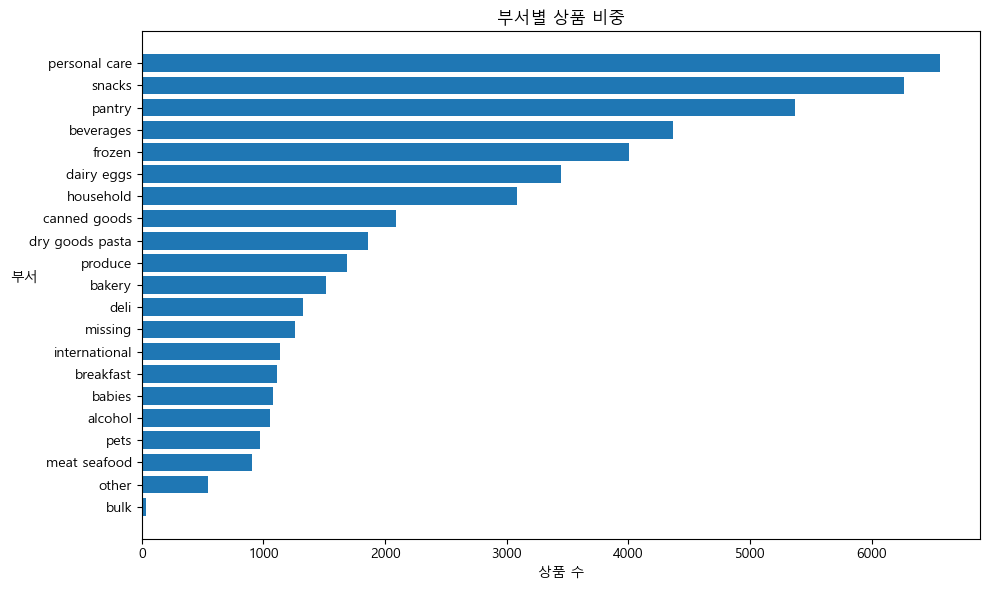


 인기 카테고리 TOP 10 (상품 기준):
        department  product_count
0    personal care           6563
1           snacks           6264
2           pantry           5371
3        beverages           4365
4           frozen           4007
5       dairy eggs           3449
6        household           3085
7     canned goods           2092
8  dry goods pasta           1858
9          produce           1684


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. 데이터 로드
# -----------------------------
products = pd.read_csv('../data/products.csv')
aisles = pd.read_csv('../data/aisles.csv')
departments = pd.read_csv('../data/departments.csv')

# -----------------------------
# 2. 데이터 병합
# -----------------------------
# products + aisles + departments
df = products.merge(aisles, on='aisle_id', how='left')
df = df.merge(departments, on='department_id', how='left')

# -----------------------------
# 3. 부서별 상품 수 분석
# -----------------------------
dept_counts = df['department'].value_counts().reset_index()
dept_counts.columns = ['department', 'product_count']

print("\n 부서별 상품 수:")
print(dept_counts.head(10))

# -----------------------------
# 4. 통로(Aisle)별 상품 수 TOP 10
# -----------------------------
aisle_counts = df['aisle'].value_counts().reset_index()
aisle_counts.columns = ['aisle', 'product_count']

top10_aisles = aisle_counts.head(10)

print("\n Aisle TOP 10:")
print(top10_aisles)

# -----------------------------
# 5. 부서별 상품 비중 차트
# -----------------------------
plt.rc('font', family='Malgun Gothic')  
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))
plt.barh(dept_counts['department'], dept_counts['product_count'])
plt.xlabel('상품 수')
plt.ylabel('부서', rotation=0)
plt.title('부서별 상품 비중')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# -----------------------------
# 6. 인기 카테고리 TOP 10 (상품 기준)
# -----------------------------
top10_departments = dept_counts.head(10)

print("\n 인기 카테고리 TOP 10 (상품 기준):")
print(top10_departments)
